# Spatial GNN

In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [2]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.models.spatial_gcn import SpatialGCNModel

n_periods = 1
n_epochs  = 100
horizon   = 4
lags      = range(0,4)

influenza = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2006-06-01',max_date='2020-06-01')
influenza.add_time_features()
influenza.log_transform_target()
influenza.normalize('2018-06-01','2019-06-01','zscore')
influenza.add_lagged_features(lags)


influenza_loader1 = GNNDataLoader(influenza).retrieve_graph('identity_graph').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
influenza_loader2 = GNNDataLoader(influenza).retrieve_graph('gravity_model_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
influenza_loader3 = GNNDataLoader(influenza).retrieve_graph('gravity_model_top8_self0_log').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)
influenza_loader4 = GNNDataLoader(influenza).retrieve_graph('boolean_neighbors_self0').construct_dataloaders(periods=n_periods, prediction_horizon=horizon)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


population_size has been removed from dataloader


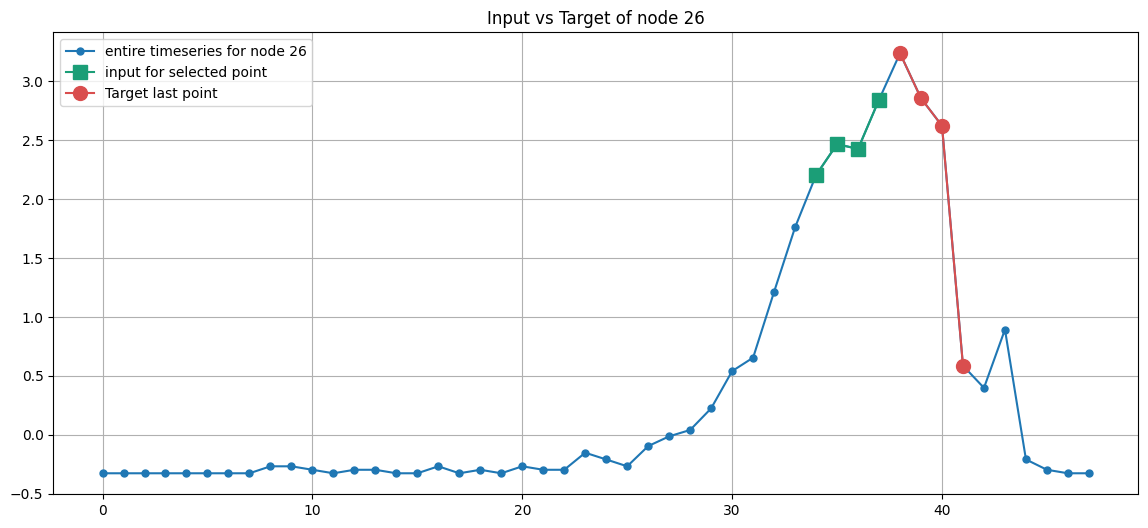

In [3]:
influenza_loader1.preview_dataloader(26, 38, 'test')

Dataloader Snapshot: Data(x=[411, 6, 1], edge_index=[2, 411], y=[411, 4], edge_weight=[411])
Epoch 1 train loss: 0.4601, val loss: 0.7077 ✓ (new best)
Epoch 11 train loss: 0.4000, val loss: 0.5120 ✓ (new best)
Epoch 21 train loss: 0.3855, val loss: 0.4993 (patience: 2/15)
Epoch 31 train loss: 0.3759, val loss: 0.4969 ✓ (new best)
Epoch 41 train loss: 0.3667, val loss: 0.4982 (patience: 8/15)
Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.4969
Test loss: 0.7703
Dataloader Snapshot: Data(x=[411, 6, 1], edge_index=[2, 2529], y=[411, 4], edge_weight=[2529])
Epoch 1 train loss: 0.5006, val loss: 0.7677 ✓ (new best)
Epoch 11 train loss: 0.4099, val loss: 0.5344 ✓ (new best)
Epoch 21 train loss: 0.3891, val loss: 0.5132 ✓ (new best)
Epoch 31 train loss: 0.3771, val loss: 0.5097 (patience: 2/15)
Epoch 41 train loss: 0.3665, val loss: 0.5098 (patience: 12/15)
Early stopping: Validation loss hasn't improved for 15 epochs
Restored model f

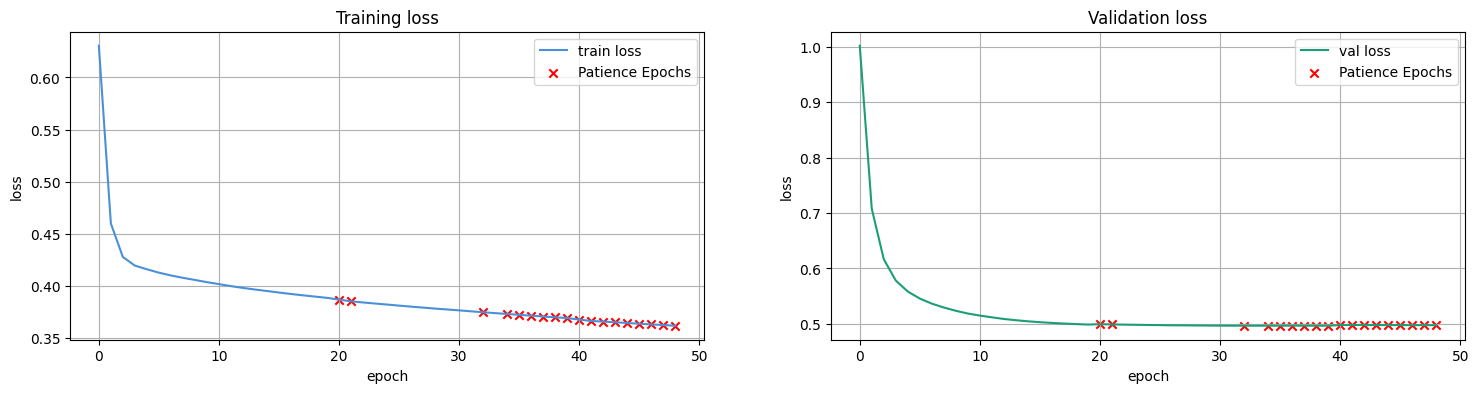

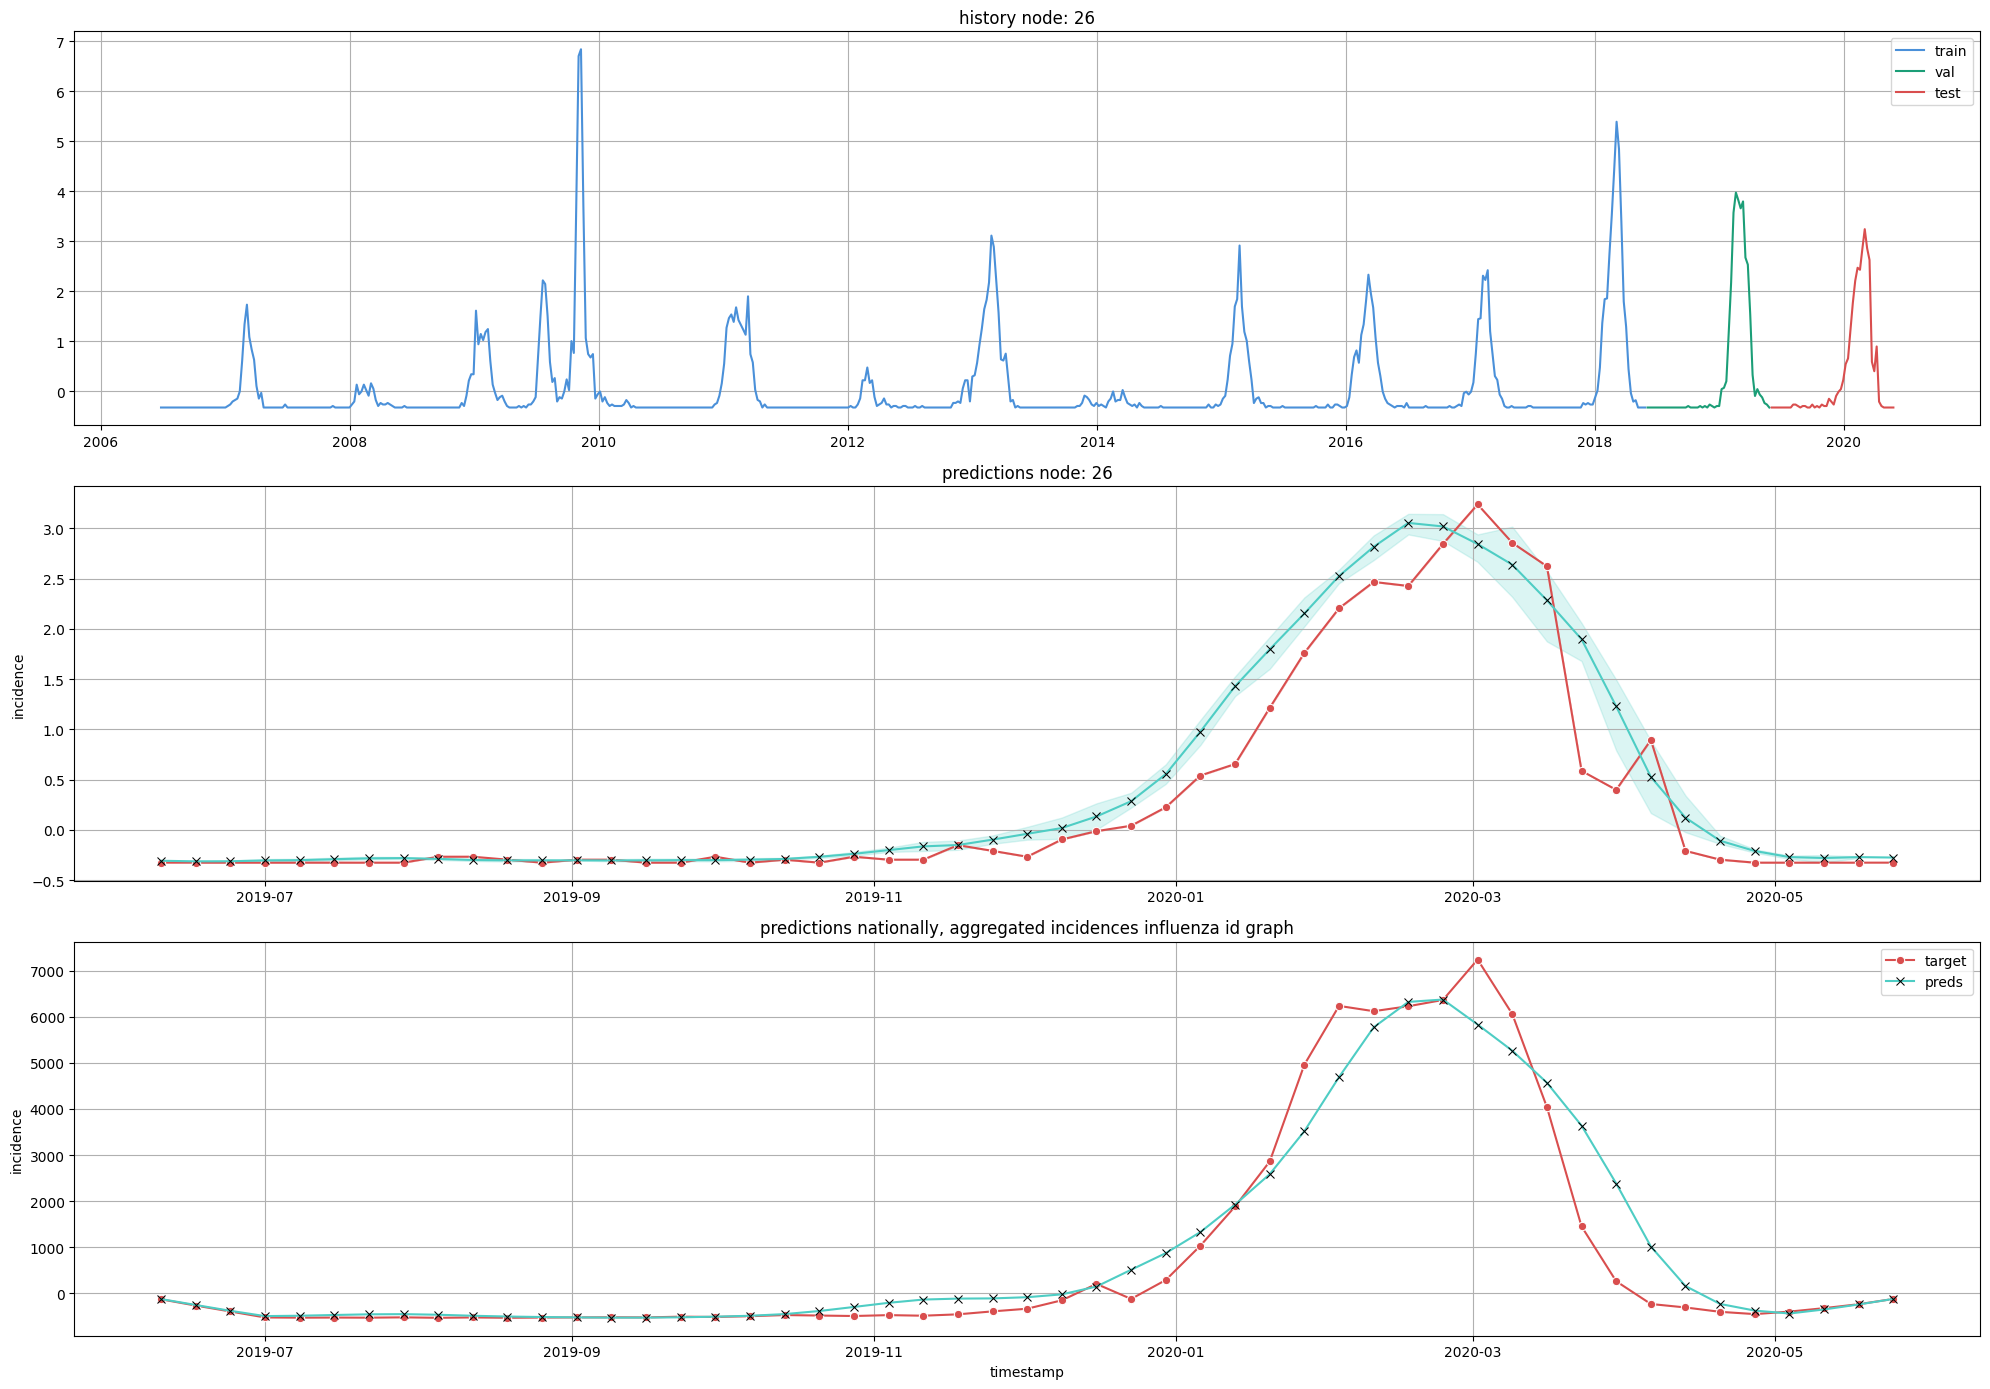

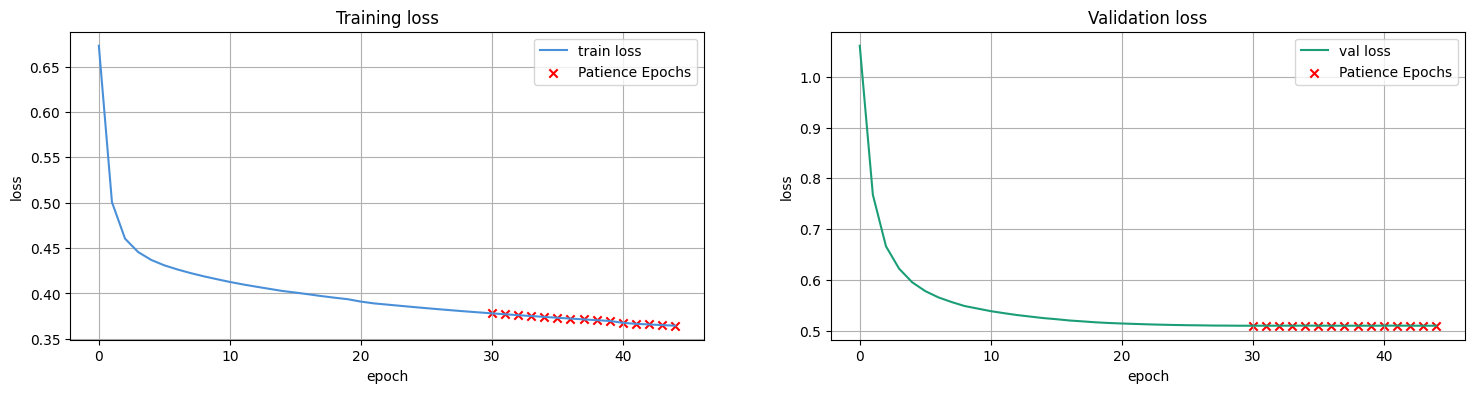

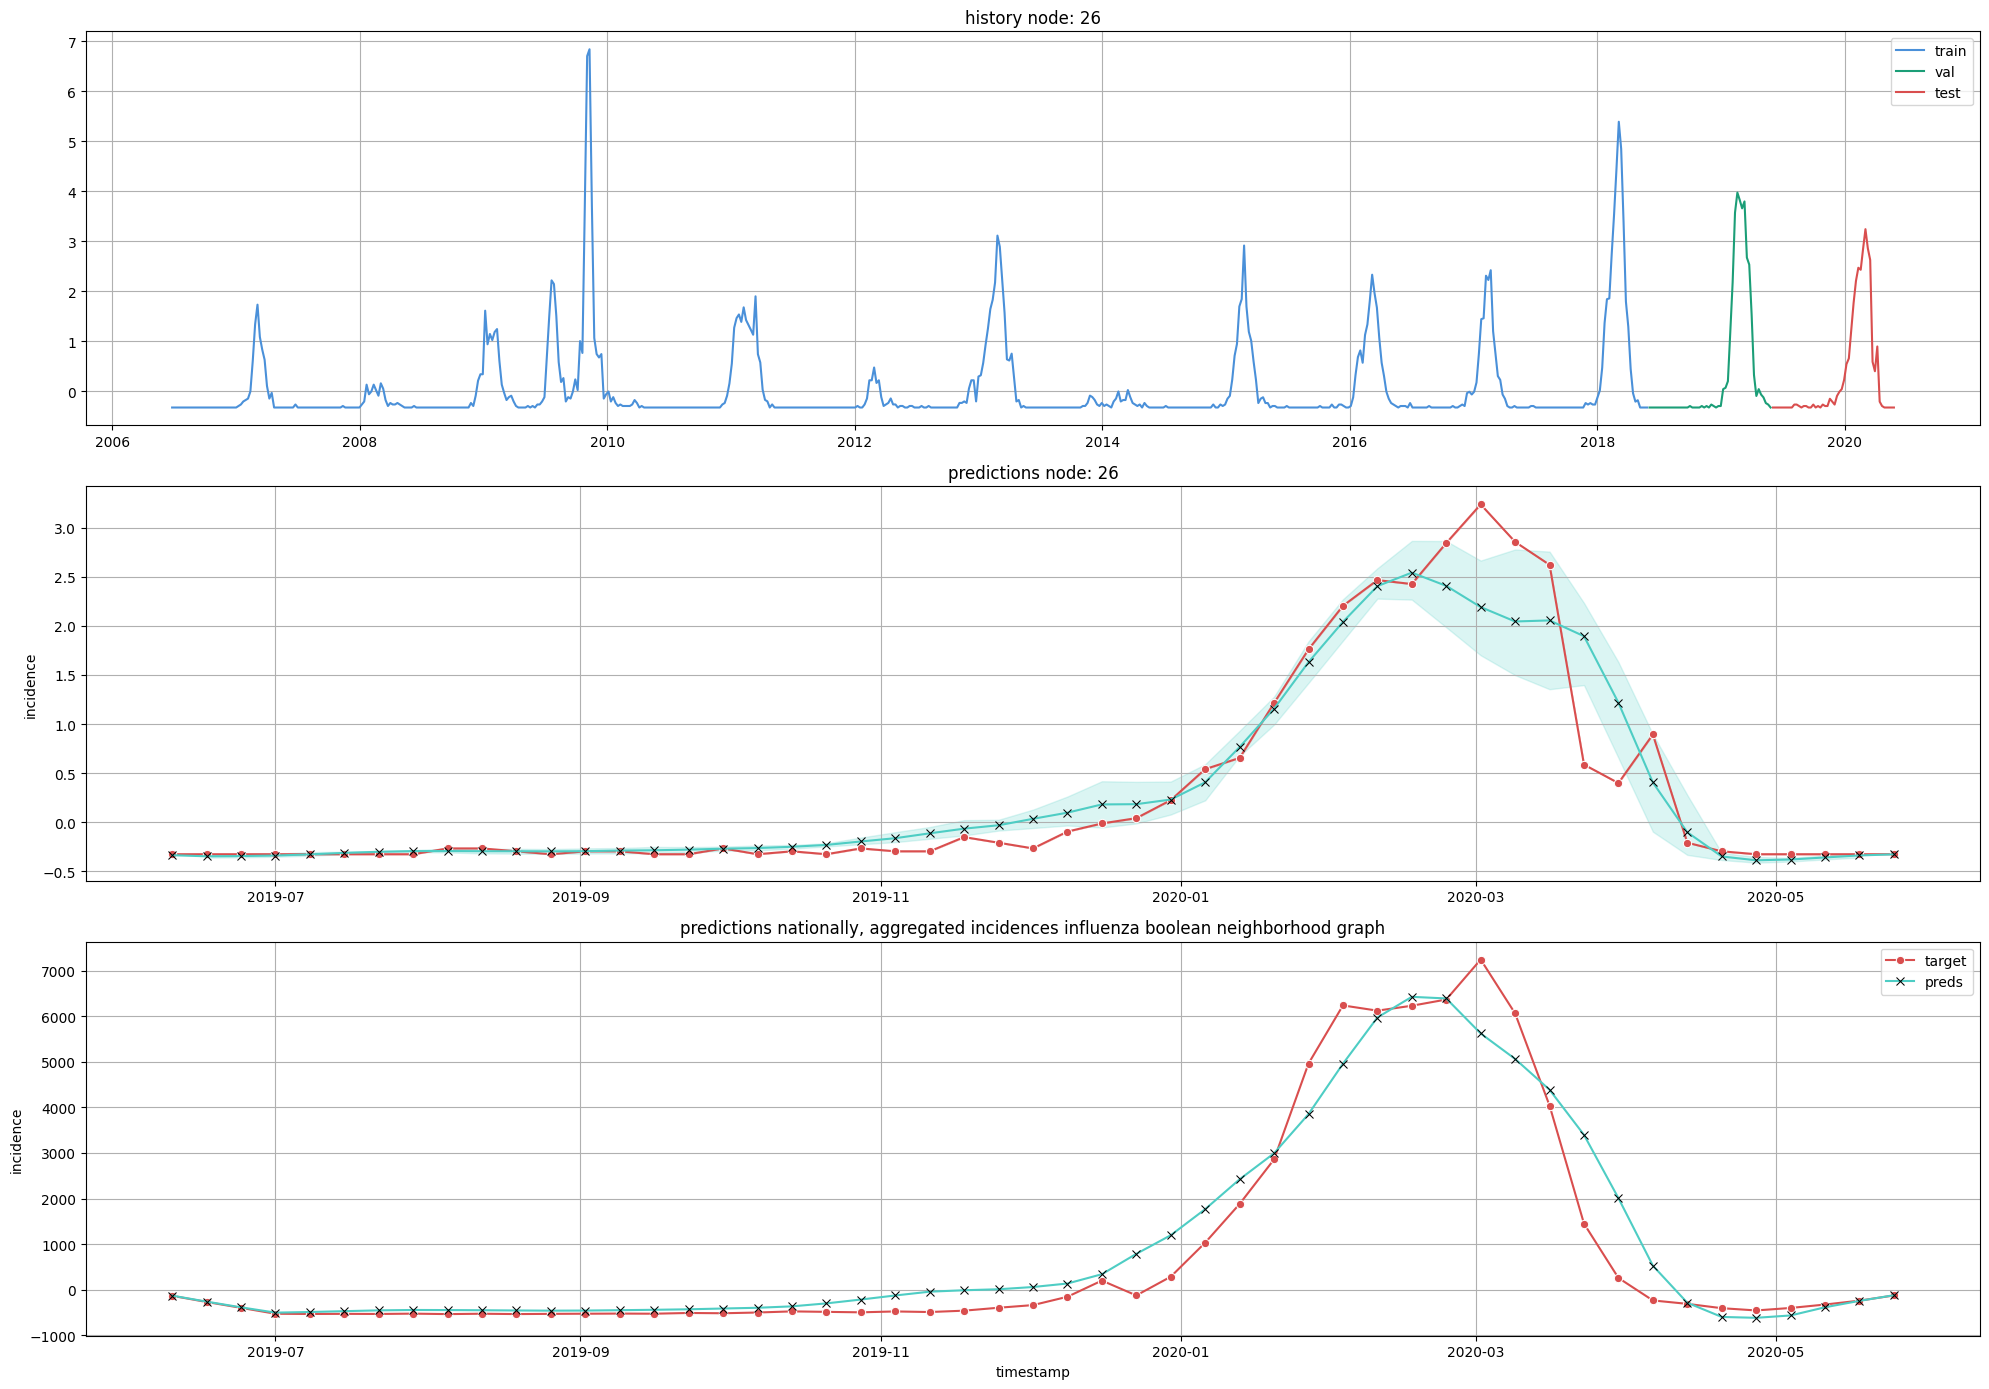

In [4]:
n_epochs = 150
lr = 0.0001

ml1 = SpatialGCNModel(name = f'influenza id graph', dataloader=influenza_loader1)
ml1.set_model_hparams()
ml1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml1.train()
ml1.forecast()
ml1.show_forecasts(26)

ml2 = SpatialGCNModel(name = f'influenza boolean neighborhood graph', dataloader=influenza_loader4)
ml2.set_model_hparams()
ml2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2.train()
ml2.forecast()
ml2.show_forecasts(26)

Test loss: 0.7703
2020-02-10 00:00:00


/home/de-schrijvers/projects/germany_gnn/src/models/modelcore.py:192: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


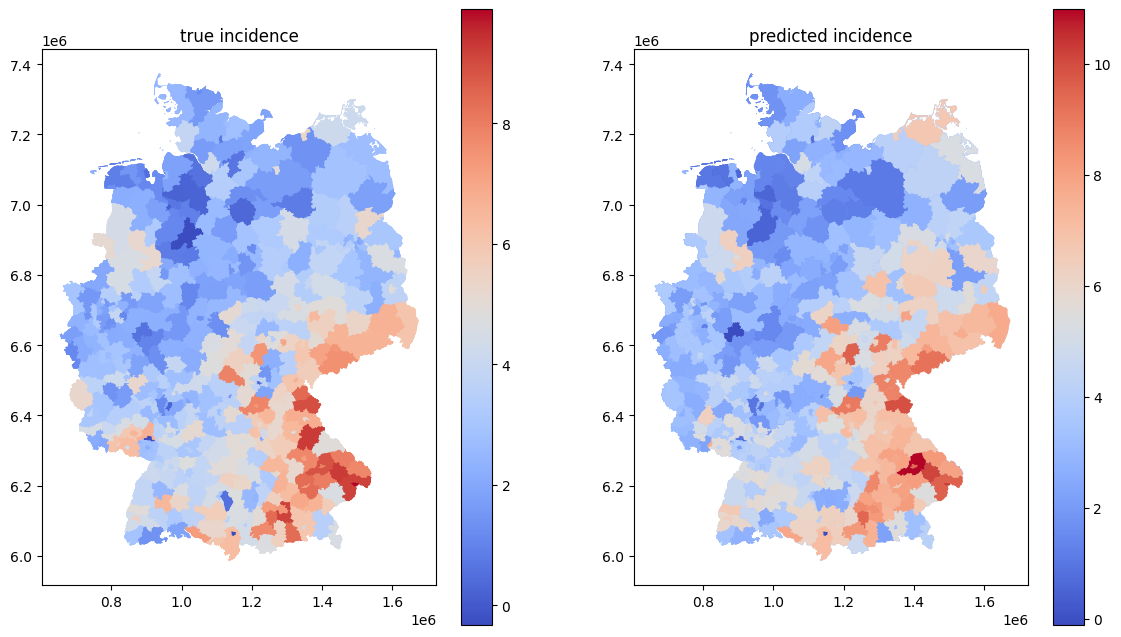

In [5]:
ml1.forecast('test')
ml1.show_forecasts_maps(35,'individual')

Test loss: 0.3622


KeyboardInterrupt: 

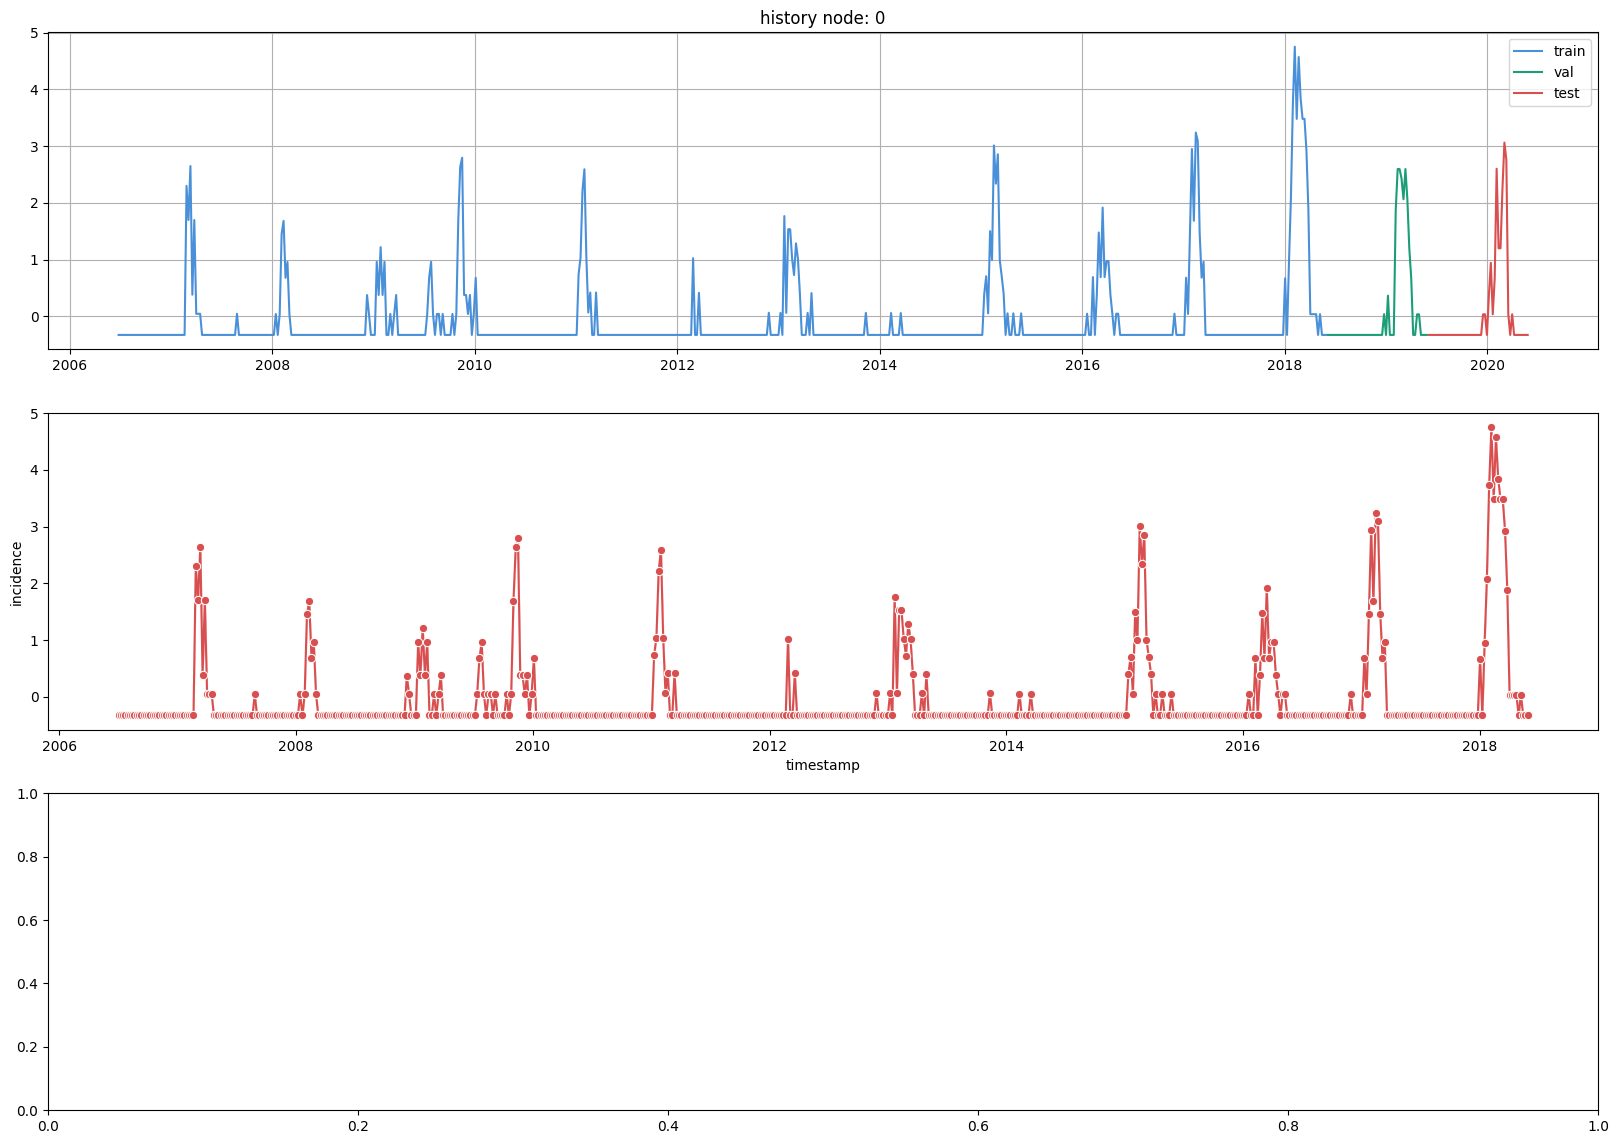

In [7]:
ml1.forecast('train')
ml1.show_forecasts()

Test loss: 0.3622


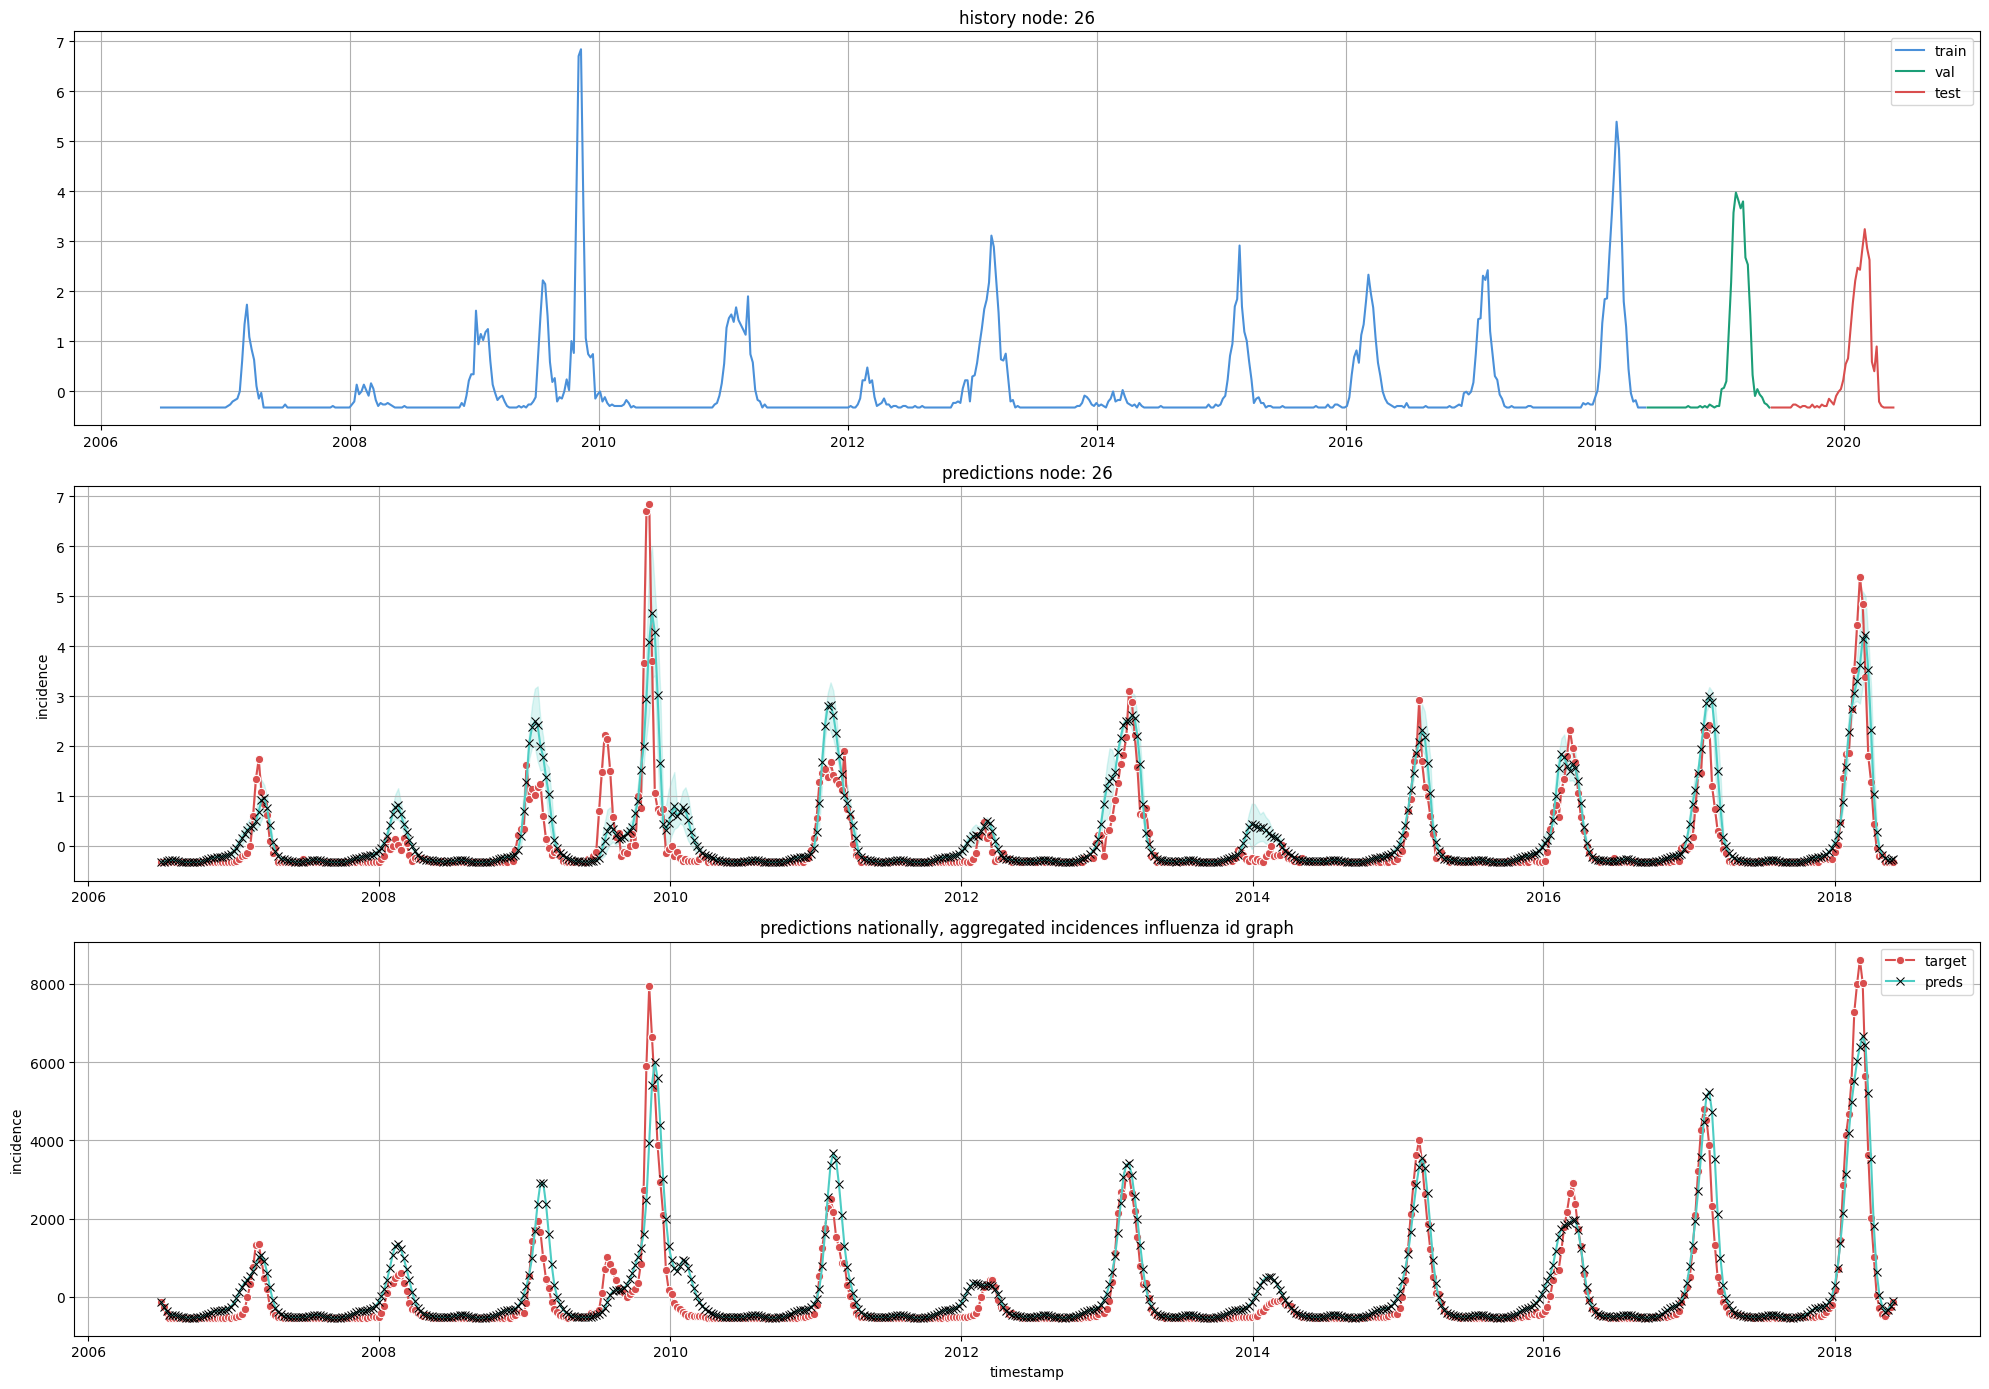

In [8]:
ml1.forecast('train')
ml1.show_forecasts(26)

2010-01-04 00:00:00


/home/de-schrijvers/projects/germany_gnn/src/models/modelcore.py:192: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


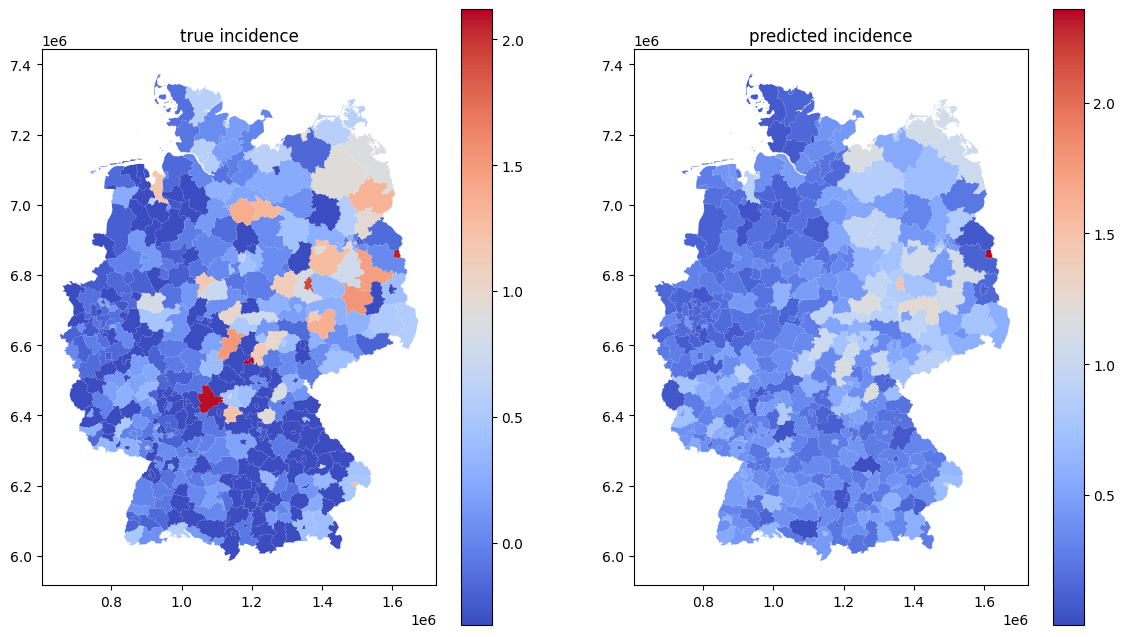

Test loss: 0.5454


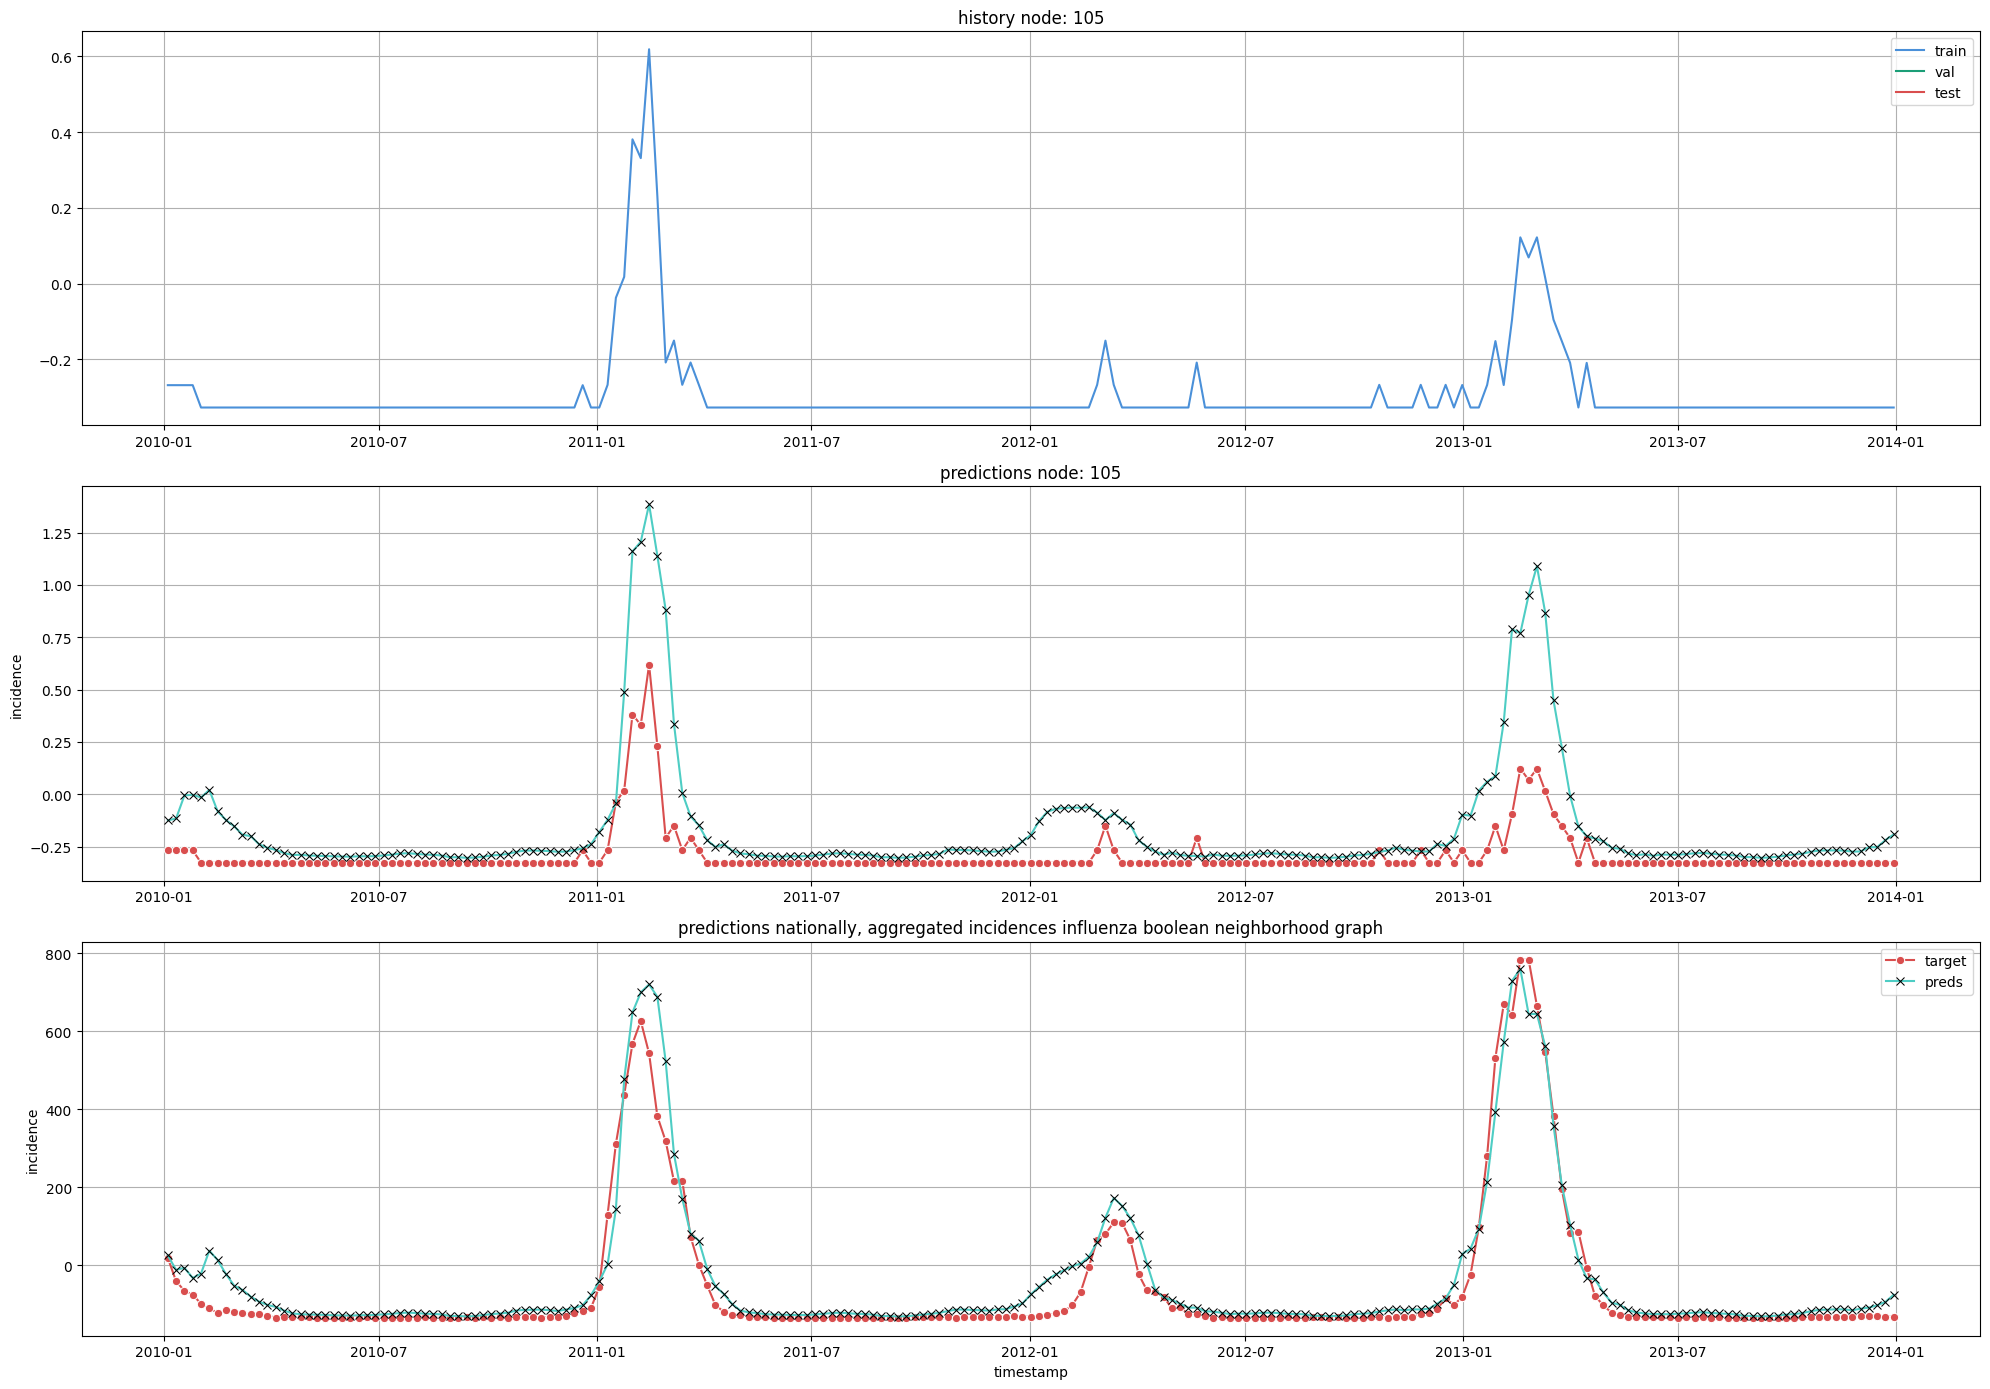

In [12]:
ml2.forecast('train')
ml2.show_forecasts(105, timeframe = ['2010-01-01','2014-01-01'])

Dataloader Snapshot: Data(x=[411, 8, 1], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 0.5995, val loss: 0.8317 ✓ (new best)
Epoch 2 train loss: 0.5853, val loss: 0.8274 ✓ (new best)
Epoch 3 train loss: 0.5777, val loss: 0.8250 ✓ (new best)
Epoch 4 train loss: 0.5711, val loss: 0.8216 ✓ (new best)
Epoch 5 train loss: 0.5664, val loss: 0.8220 (patience: 1/15)
Epoch 6 train loss: 0.5624, val loss: 0.8206 ✓ (new best)
Epoch 7 train loss: 0.5597, val loss: 0.8185 ✓ (new best)
Epoch 8 train loss: 0.5570, val loss: 0.8171 ✓ (new best)
Epoch 9 train loss: 0.5547, val loss: 0.8155 ✓ (new best)
Epoch 10 train loss: 0.5528, val loss: 0.7936 ✓ (new best)
Epoch 11 train loss: 0.5462, val loss: 0.7908 ✓ (new best)
Epoch 12 train loss: 0.5447, val loss: 0.7904 ✓ (new best)
Epoch 13 train loss: 0.5433, val loss: 0.7907 (patience: 1/15)
Epoch 14 train loss: 0.5424, val loss: 0.7894 ✓ (new best)
Epoch 15 train loss: 0.5407, val loss: 0.7894 (patience: 1/15)
Epoch 16 train lo

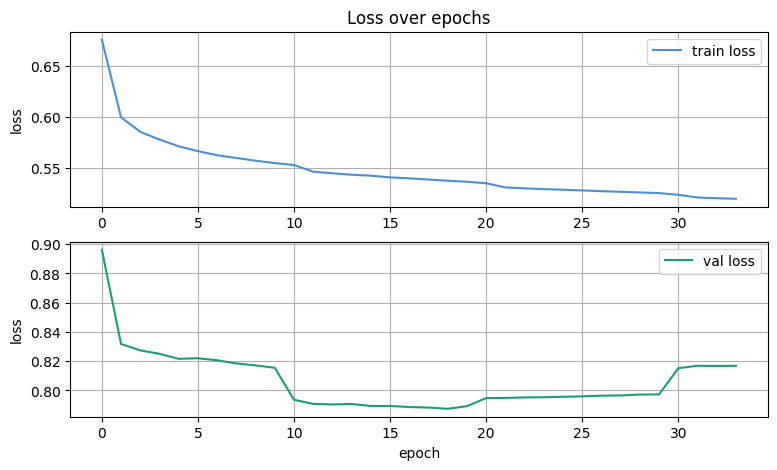

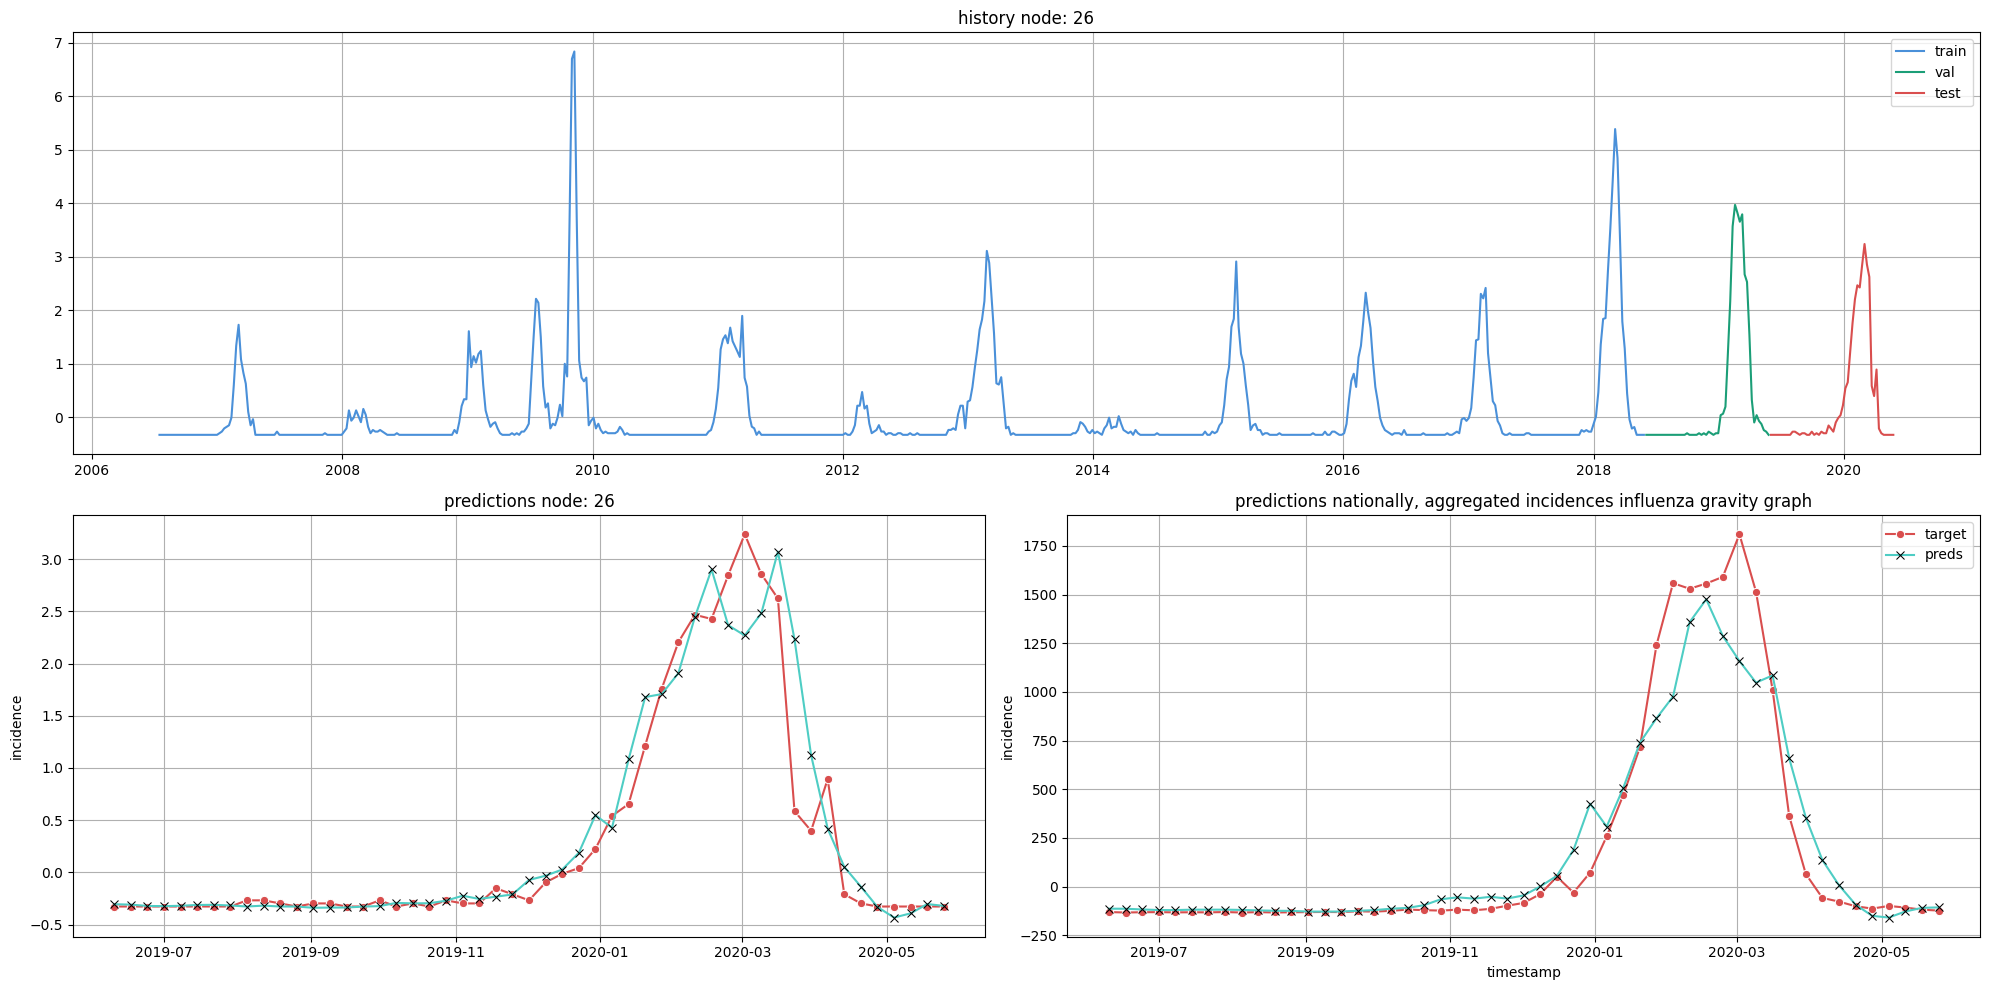

In [11]:
n_epochs = 200

ml = SpatialGCNModel(name = f'influenza gravity graph', dataloader=influenza_loader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.0001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train()
ml.forecast()
ml.show_forecasts(26)

2020-01-06 00:00:00


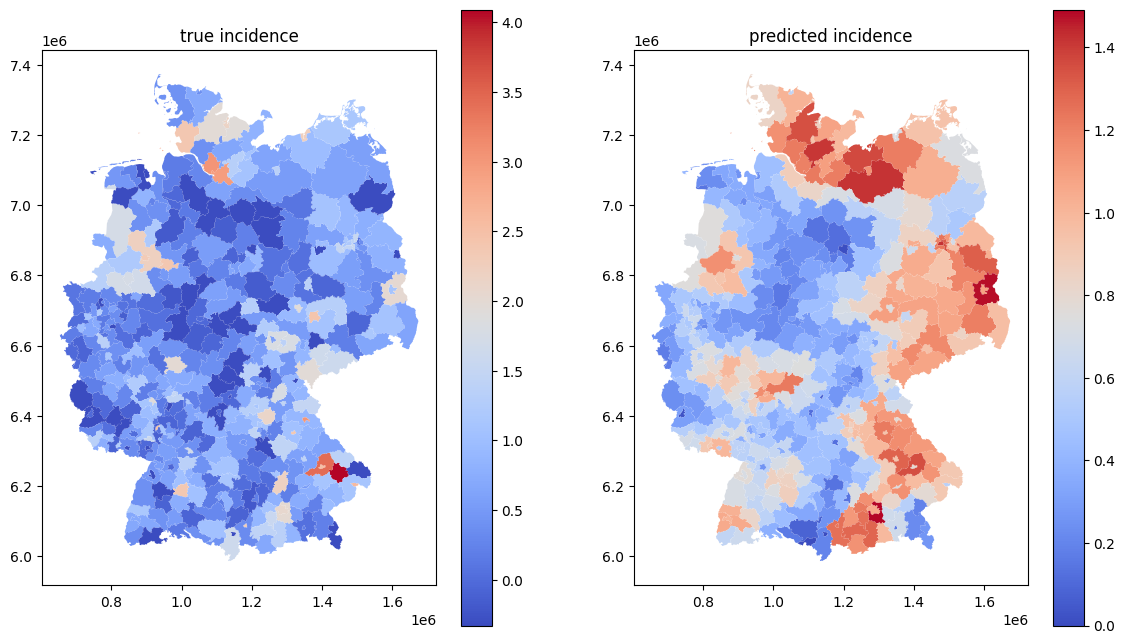

In [ ]:
ml.

Test loss: 0.8011


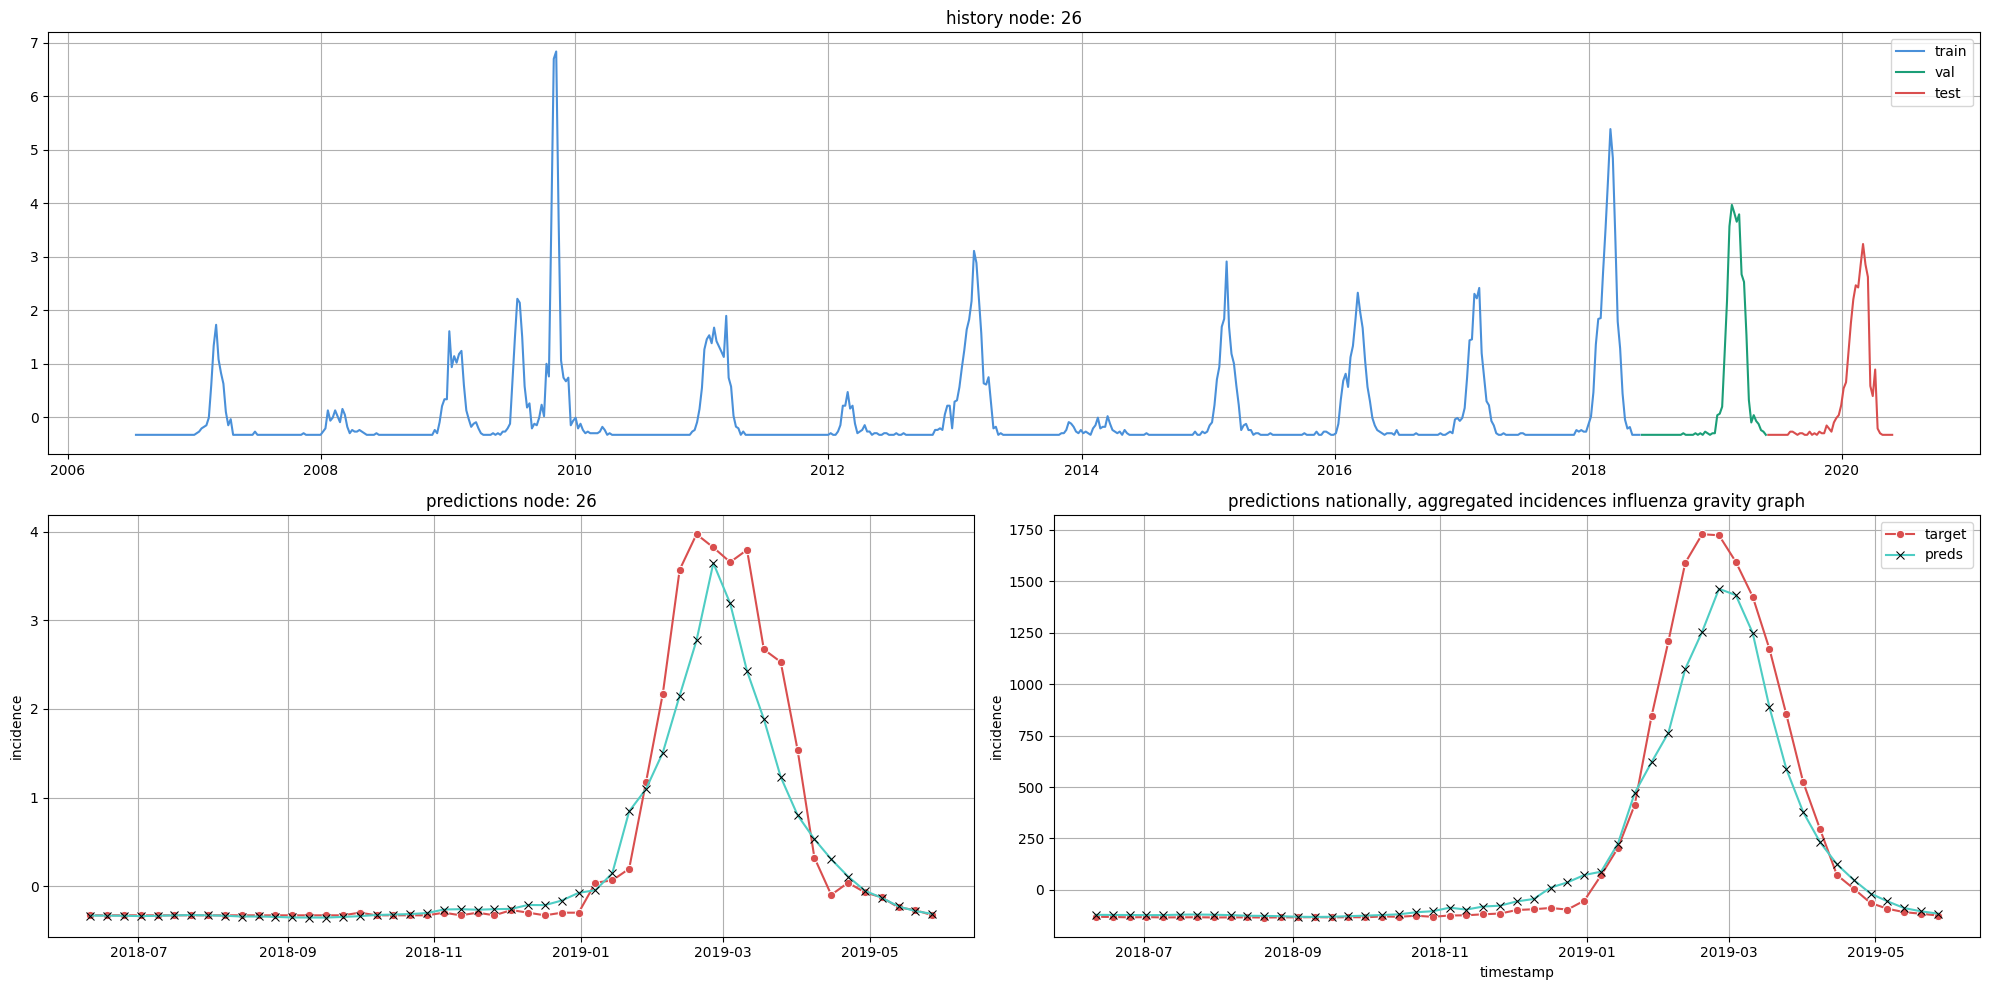

In [14]:
ml.forecast(dataset = 'val')
ml.show_forecasts(26)

Dataloader Snapshot: Data(x=[411, 9, 1], edge_index=[2, 4255], y=[411, 1], edge_weight=[4255])
Epoch 1 train loss: 0.9458, val loss: 0.6490 ✓ (new best)
Epoch 2 train loss: 0.8945, val loss: 0.6153 ✓ (new best)
Epoch 3 train loss: 0.8507, val loss: 0.5887 ✓ (new best)
Epoch 4 train loss: 0.8156, val loss: 0.5710 ✓ (new best)
Epoch 5 train loss: 0.7903, val loss: 0.5612 ✓ (new best)
Epoch 6 train loss: 0.7732, val loss: 0.5570 ✓ (new best)
Epoch 7 train loss: 0.7618, val loss: 0.5558 ✓ (new best)
Epoch 8 train loss: 0.7541, val loss: 0.5558 (patience: 1/20)
Epoch 9 train loss: 0.7486, val loss: 0.5562 (patience: 2/20)
Epoch 10 train loss: 0.7445, val loss: 0.5565 (patience: 3/20)
Epoch 11 train loss: 0.7413, val loss: 0.5568 (patience: 4/20)
Epoch 12 train loss: 0.7387, val loss: 0.5570 (patience: 5/20)
Epoch 13 train loss: 0.7364, val loss: 0.5571 (patience: 6/20)
Epoch 14 train loss: 0.7344, val loss: 0.5572 (patience: 7/20)
Epoch 15 train loss: 0.7326, val loss: 0.5573 (patience: 8/2

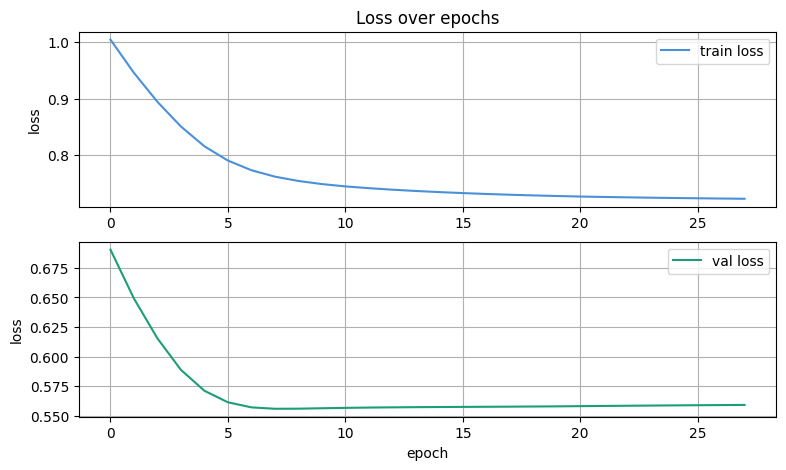

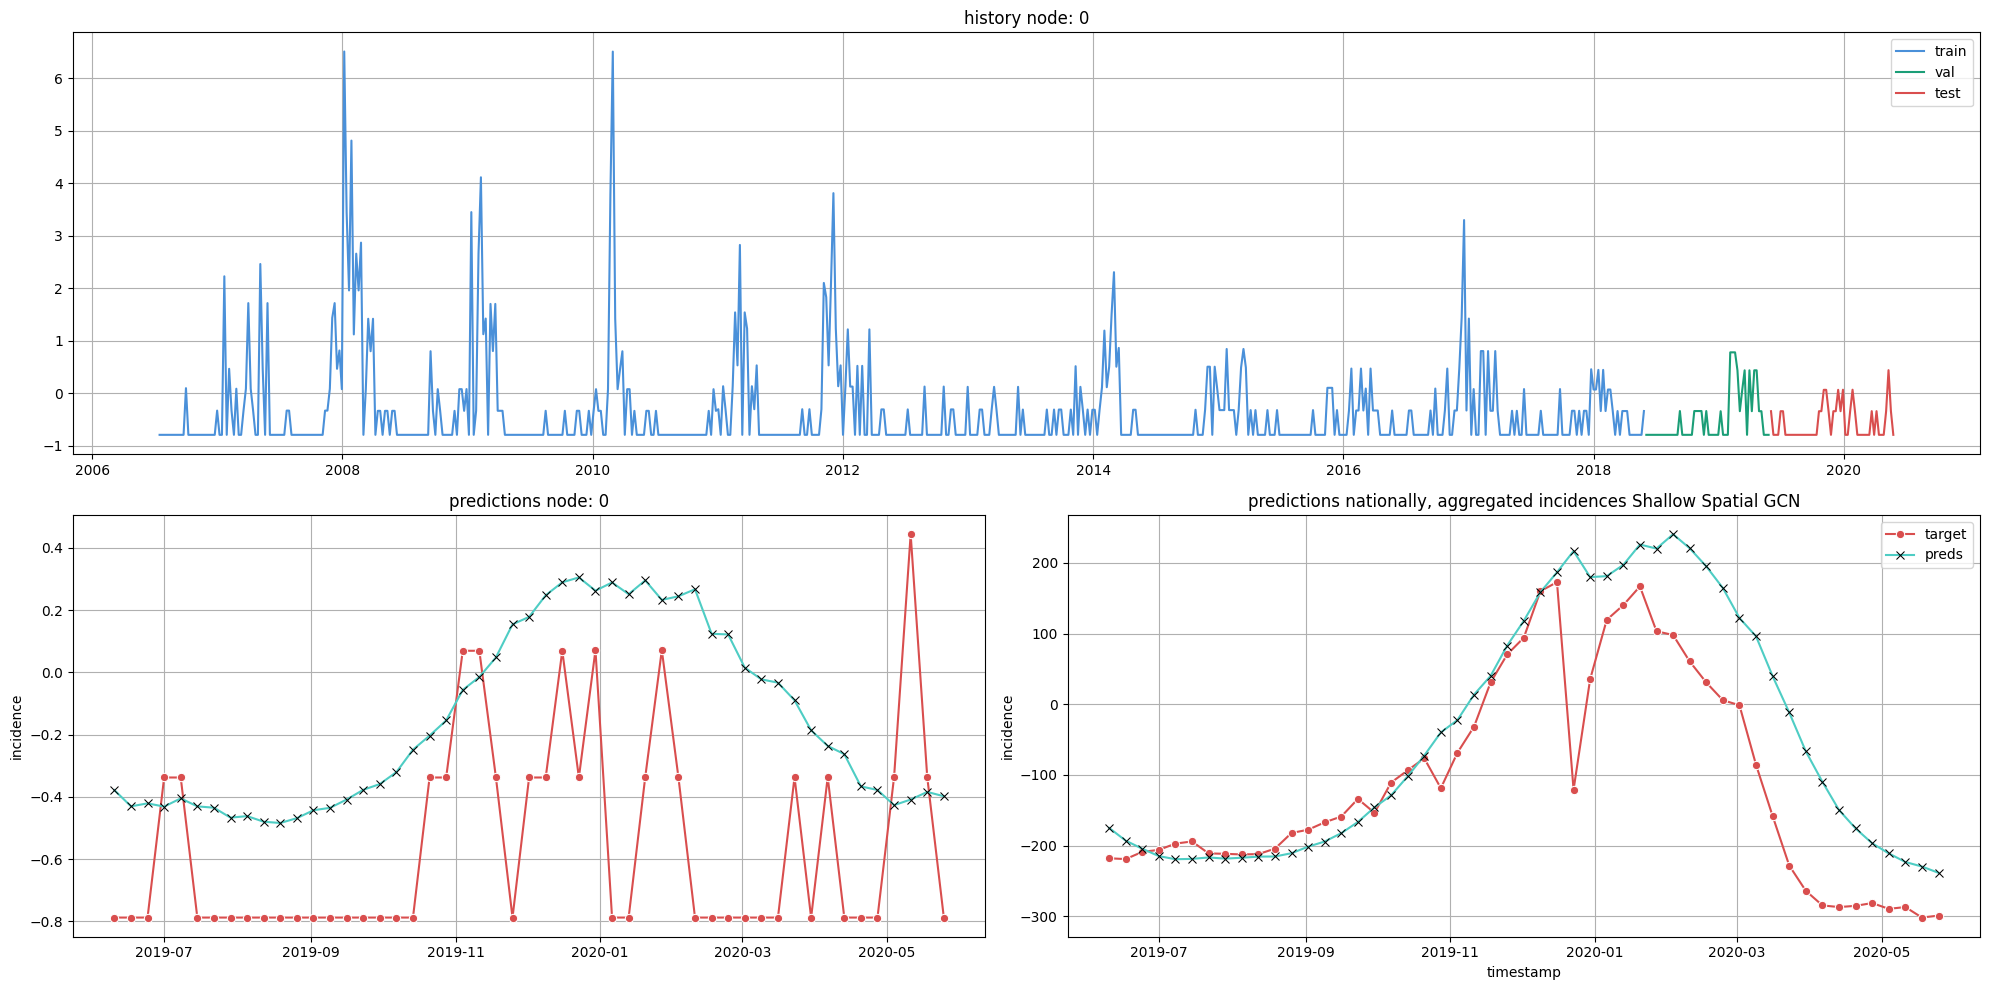

In [116]:
n_epochs = 100

ml = SpatialGCNModel(name = f'Shallow Spatial GCN', dataloader=noro_loader2)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00001, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.9}, min_delta = 0.000001, loss = 'mse', patience = 20)
ml.train()
ml.forecast()
ml.show_forecasts()

CAREFUL! MULTIPLE LAGS MAY NOT BE HANDLED PROPERLY YET


UnboundLocalError: cannot access local variable 'lag' where it is not associated with a value

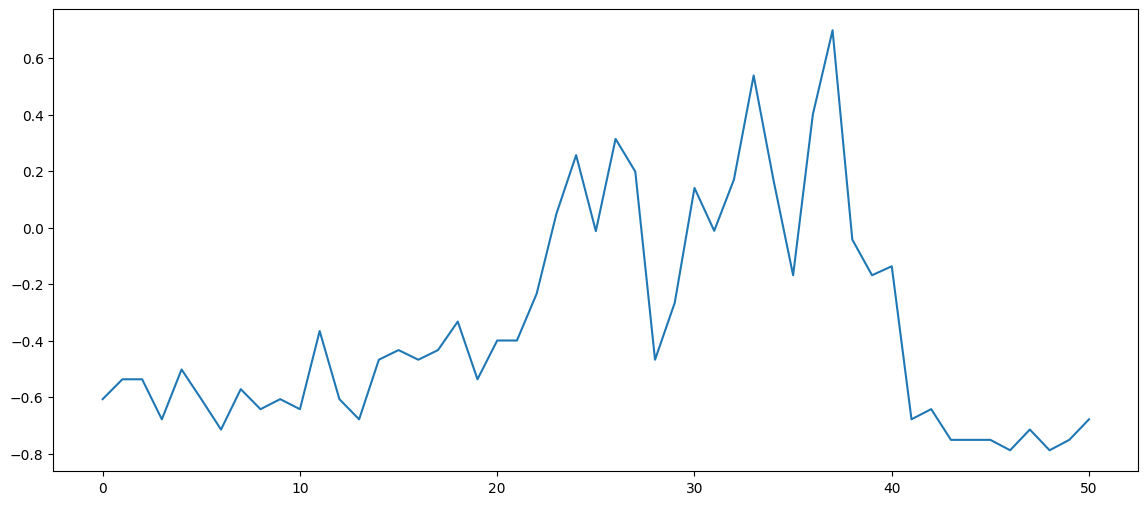

In [118]:
noro_loader2.preview_dataloader(26)

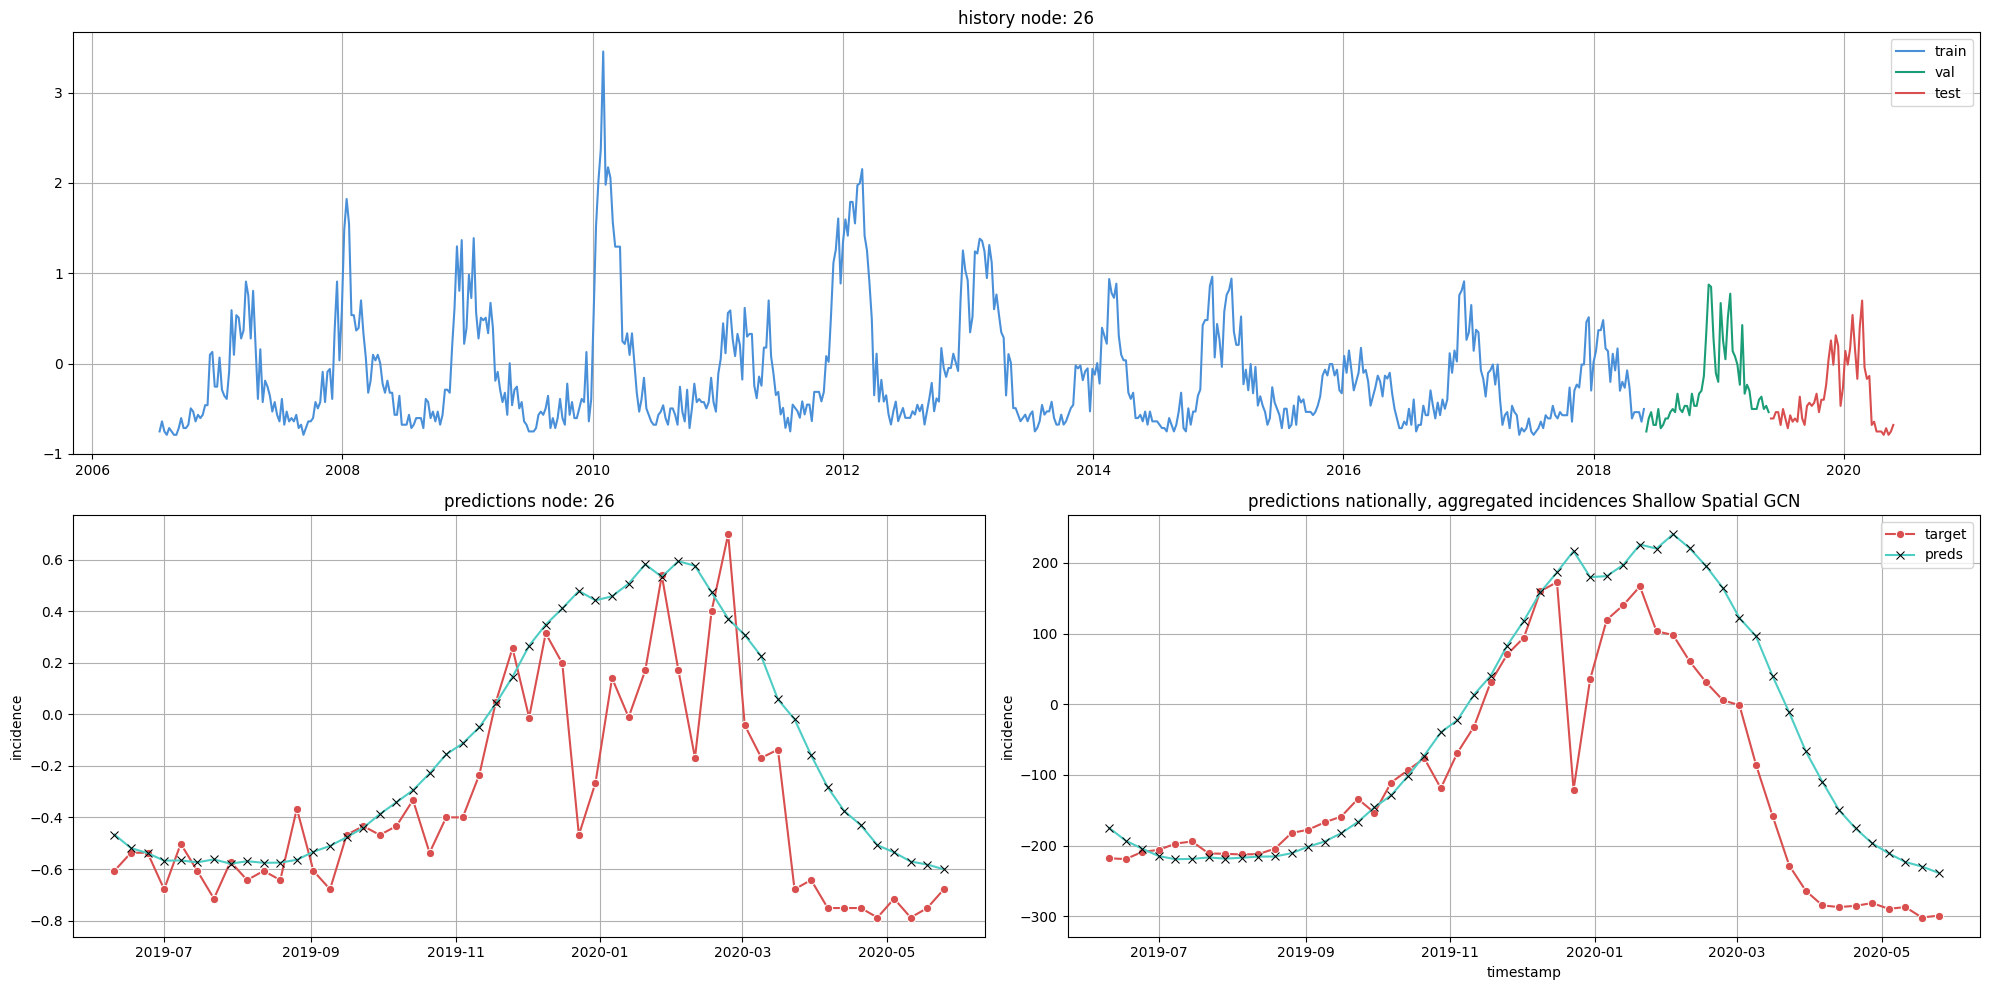

In [117]:
ml.show_forecasts(26)

Dataloader Snapshot: Data(x=[411, 9, 1], edge_index=[2, 3695], y=[411, 1], edge_weight=[3695])
Epoch 1 train loss: 0.7527, val loss: 1.6083 ✓ (new best)
Epoch 2 train loss: 0.7117, val loss: 1.4913 ✓ (new best)
Epoch 3 train loss: 0.6897, val loss: 1.4270 ✓ (new best)
Epoch 4 train loss: 0.6760, val loss: 1.3885 ✓ (new best)
Epoch 5 train loss: 0.6668, val loss: 1.3645 ✓ (new best)
Epoch 6 train loss: 0.6599, val loss: 1.3486 ✓ (new best)
Epoch 7 train loss: 0.6546, val loss: 1.3377 ✓ (new best)
Epoch 8 train loss: 0.6501, val loss: 1.3298 ✓ (new best)
Epoch 9 train loss: 0.6460, val loss: 1.3238 ✓ (new best)
Epoch 10 train loss: 0.6421, val loss: 1.3291 (patience: 1/15)
Epoch 11 train loss: 0.6389, val loss: 1.3273 (patience: 2/15)
Epoch 12 train loss: 0.6364, val loss: 1.3244 (patience: 3/15)
Epoch 13 train loss: 0.6341, val loss: 1.3213 ✓ (new best)
Epoch 14 train loss: 0.6320, val loss: 1.3182 ✓ (new best)
Epoch 15 train loss: 0.6300, val loss: 1.3150 ✓ (new best)
Epoch 16 train lo

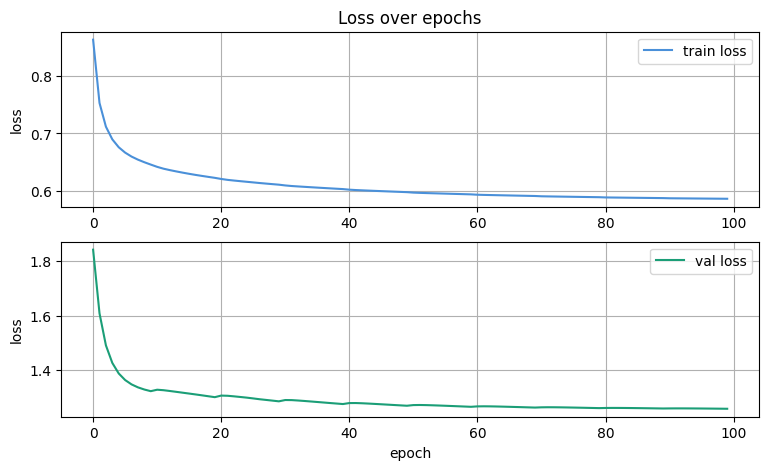

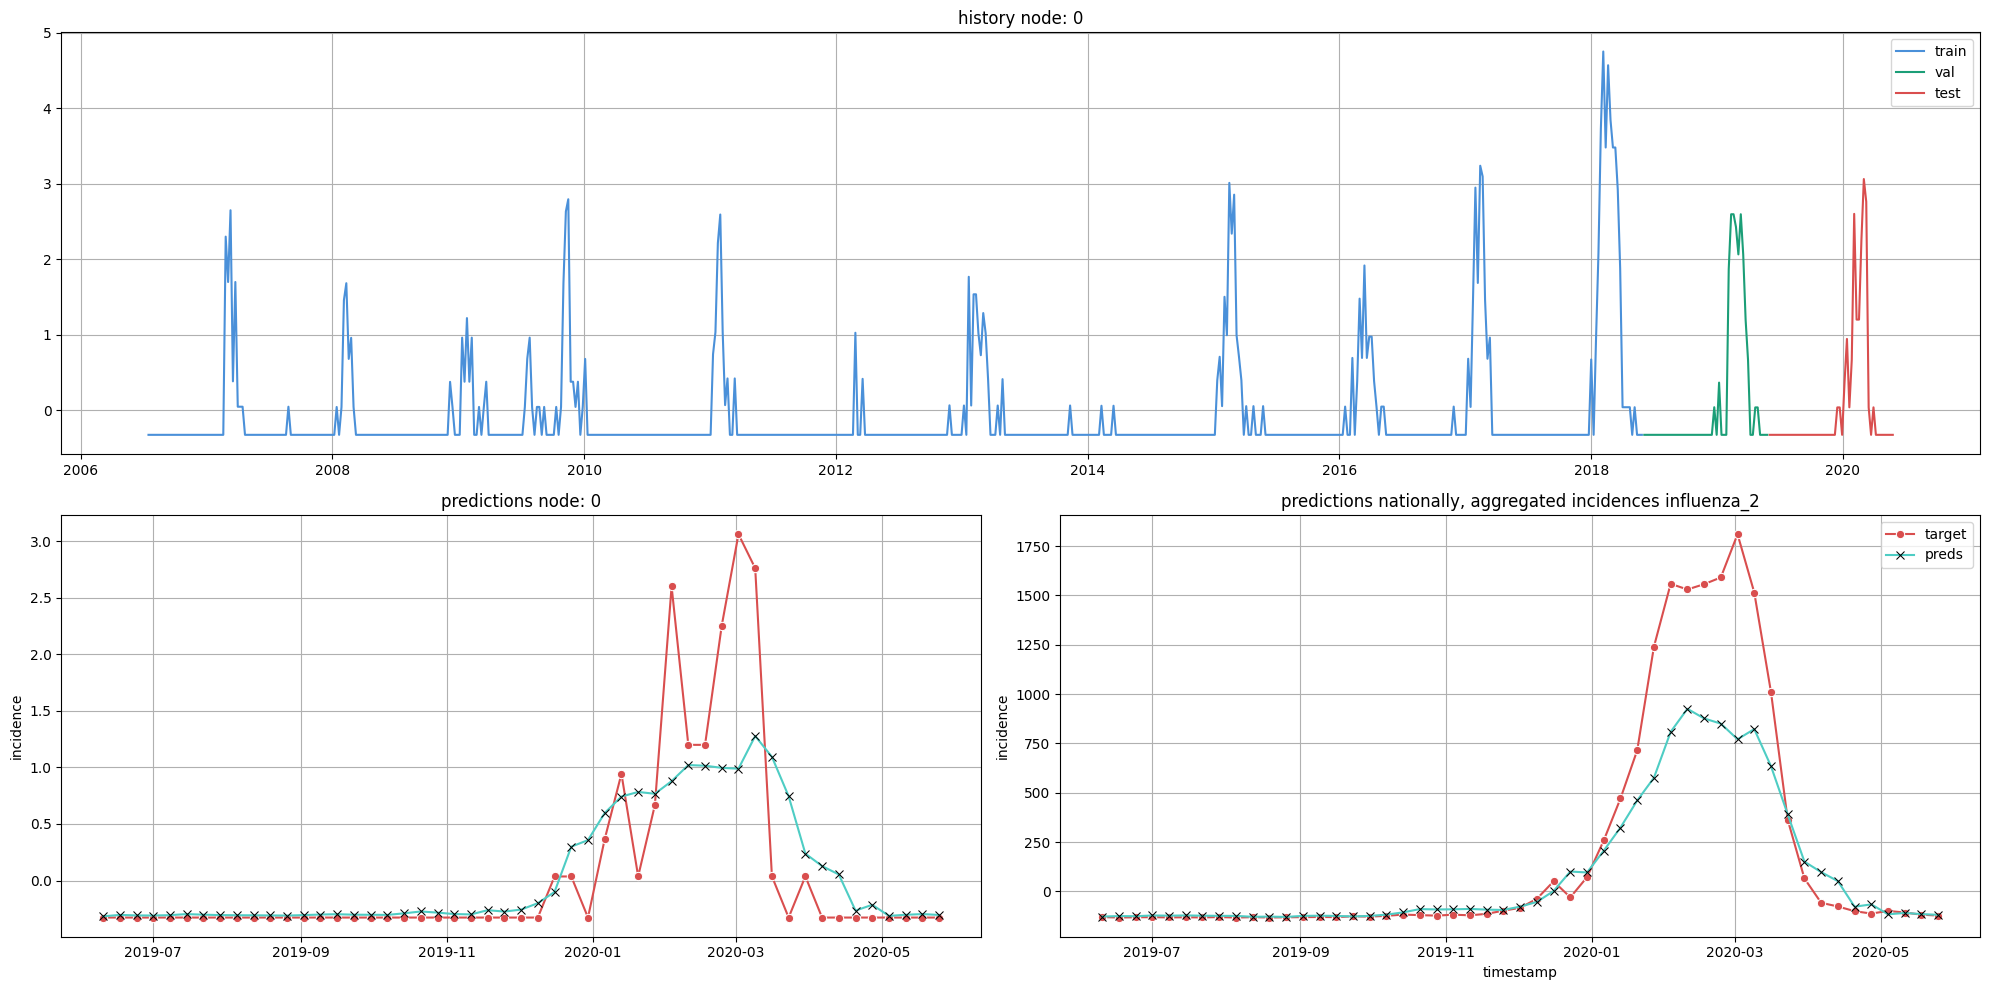

In [74]:
n_epochs = 100

ml = SpatialGCNModel(name = f'influenza_2', dataloader=influenza_loader3)
ml.set_model_hparams()
ml.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':10, 'gamma':0.75}, min_delta = 0.00001, loss = 'mse')
ml.train()
ml.forecast()
ml.show_forecasts()